# Assignment 5 — Landsat NDVI and Crop Greenness Analysis

This notebook documents a reproducible real-data workflow using authentic
USGS Landsat Collection 2 Level-2 imagery accessed through Microsoft
Planetary Computer.

The analysis uses the largest validated Assignment 2 field and computes
single-date NDVI from Landsat Red and near-infrared surface reflectance.
No synthetic, generated, substituted, or mock imagery is used.

In [1]:
from pathlib import Path
import hashlib
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from PIL import Image
from IPython.display import display

# nbconvert normally executes the notebook with the
# notebooks directory as its working directory.
working_directory = Path.cwd().resolve()

if (
    working_directory / "data/assignment-05"
).is_dir():
    ROOT = working_directory
elif (
    working_directory.parent / "data/assignment-05"
).is_dir():
    ROOT = working_directory.parent
else:
    raise RuntimeError(
        "Could not locate the repository root "
        "containing data/assignment-05."
    )

A5 = ROOT / "data/assignment-05"

SUMMARY_PATH = A5 / "output/ndvi_summary.json"
MANIFEST_PATH = A5 / "source/source_manifest.json"

summary = json.loads(SUMMARY_PATH.read_text(encoding="utf-8"))
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))

assert summary["status"] == "complete"
assert manifest["status"] == "acquired"
assert summary["no_synthetic_fallback_used"] is True
assert manifest["no_synthetic_fallback_used"] is True

print("Product ID:", summary["product_id"])
print("Platform:", summary["platform"])
print("Acquisition:", summary["acquisition_datetime"])
print("Field ID:", summary["field_id"])
print("Field acres:", summary["field_acres"])
print("2023 CDL label:", summary["crop_2023"])
print("PASS: Authentic source and completed summary loaded.")

Product ID: LC08_L2SP_018036_20230727_02_T1
Platform: landsat-8
Acquisition: 2023-07-27T16:05:59.161620Z
Field ID: 451623001001257
Field acres: 19.14119405324898
2023 CDL label: Other Hay/Non Alfalfa
PASS: Authentic source and completed summary loaded.


## Study field and Landsat source

The field was selected deterministically as the largest validated field from
Assignment 2. A 300 m context buffer was used for Landsat scene-quality
evaluation. Final NDVI statistics are calculated only for pixels intersecting
the selected field.

The selected Landsat product is recorded in the source manifest together with
the Red, NIR, QA_PIXEL, and QA_RADSAT source URLs and SHA-256 checksums.

In [2]:
source_table = pd.DataFrame(
    [
        {
            "asset": asset,
            "local_path": record["path"],
            "stac_asset": record["stac_asset"],
            "sha256": record["sha256"],
        }
        for asset, record in manifest["assets"].items()
    ]
)

display(source_table)

assert set(source_table["asset"]) == {
    "red",
    "nir",
    "qa_pixel",
    "qa_radsat",
}

print("PASS: All required authentic source assets are documented.")

,asset,local_path,stac_asset,sha256
0,red,data/assignment-05/source/raw/red.tif,red,a70629e815e7b9d2fc69c3d103ae58cbd5ba9d033370f6...
1,nir,data/assignment-05/source/raw/nir.tif,nir08,f3da92b09da4868c4c43ac5520b8f315a23fb365375f9a...
2,qa_pixel,data/assignment-05/source/raw/qa_pixel.tif,qa_pixel,dbc213815760ded72bc4f3d3c5c23049c67b537bc24846...
3,qa_radsat,data/assignment-05/source/raw/qa_radsat.tif,qa_radsat,cb72ed8dd2667311faf5717abee409dcad5c8591d30412...


PASS: All required authentic source assets are documented.


## Surface-reflectance scaling and quality masking

Landsat Collection 2 Level-2 optical digital numbers are converted to surface
reflectance using the scale and offset recorded in the selected STAC
`raster:bands` metadata.

Invalid pixels are excluded when any of these conditions apply:

- QA_PIXEL bit 0: fill
- QA_PIXEL bit 1: dilated cloud
- QA_PIXEL bit 2: cirrus
- QA_PIXEL bit 3: cloud
- QA_PIXEL bit 4: cloud shadow
- QA_PIXEL bit 5: snow
- Any nonzero QA_RADSAT value
- Source fill or nodata
- Nonfinite or negative scaled reflectance
- Near-zero NDVI denominator
- Pixel outside the selected field

NDVI is calculated as `(NIR - Red) / (NIR + Red)`.

In [3]:
reflectance = summary["surface_reflectance"]
quality = summary["quality_mask"]

print("Reflectance scale:", reflectance["scale"])
print("Reflectance offset:", reflectance["offset"])
print(
    "Validated against official values:",
    reflectance["official_value_validation"],
)
print("Rejected QA_PIXEL bits:", quality["qa_pixel_rejected_bits"])
print("QA_RADSAT rule:", quality["qa_radsat_rule"])

assert np.isclose(reflectance["scale"], 0.0000275)
assert np.isclose(reflectance["offset"], -0.2)
assert quality["qa_pixel_rejected_bits"] == [0, 1, 2, 3, 4, 5]

print("PASS: Scaling and quality-mask configuration validated.")

Reflectance scale: 2.75e-05
Reflectance offset: -0.2
Validated against official values: True
Rejected QA_PIXEL bits: [0, 1, 2, 3, 4, 5]
QA_RADSAT rule: Reject every nonzero value.
PASS: Scaling and quality-mask configuration validated.


## NDVI raster integrity

In [4]:
raster_paths = {
    name: ROOT / path
    for name, path in summary["rasters"].items()
}

records = []

for name, path in raster_paths.items():
    assert path.is_file(), path

    with rasterio.open(path) as src:
        array = src.read(1, masked=True)
        valid = array.compressed()

        records.append(
            {
                "layer": name,
                "width": src.width,
                "height": src.height,
                "crs": str(src.crs),
                "resolution_x": src.res[0],
                "resolution_y": src.res[1],
                "valid_pixels": valid.size,
                "minimum": (
                    float(np.min(valid))
                    if valid.size
                    else np.nan
                ),
                "maximum": (
                    float(np.max(valid))
                    if valid.size
                    else np.nan
                ),
            }
        )

raster_table = pd.DataFrame(records)
display(raster_table)

ndvi_path = raster_paths["ndvi"]

with rasterio.open(ndvi_path) as src:
    ndvi = src.read(1, masked=True)
    ndvi_valid = ndvi.compressed()

assert ndvi_valid.size == summary["valid_pixel_count"]
assert float(np.min(ndvi_valid)) >= -1.0
assert float(np.max(ndvi_valid)) <= 1.0

print("PASS: NDVI raster is authentic, readable, and within [-1, 1].")

,layer,width,height,crs,resolution_x,resolution_y,valid_pixels,minimum,maximum
0,red,12,13,EPSG:32617,30.0,30.0,87,0.027040,0.086742
1,nir,12,13,EPSG:32617,30.0,30.0,87,0.300912,0.423095
2,qa_pixel,12,13,EPSG:32617,30.0,30.0,87,21824.000000,21824.000000
3,qa_radsat,12,13,EPSG:32617,30.0,30.0,87,0.000000,0.000000
4,ndvi,12,13,EPSG:32617,30.0,30.0,87,0.593474,0.861223


PASS: NDVI raster is authentic, readable, and within [-1, 1].


## Single-band imagery

The Red and NIR maps below are derived from the authentic Landsat surface
reflectance rasters after field masking and quality filtering.

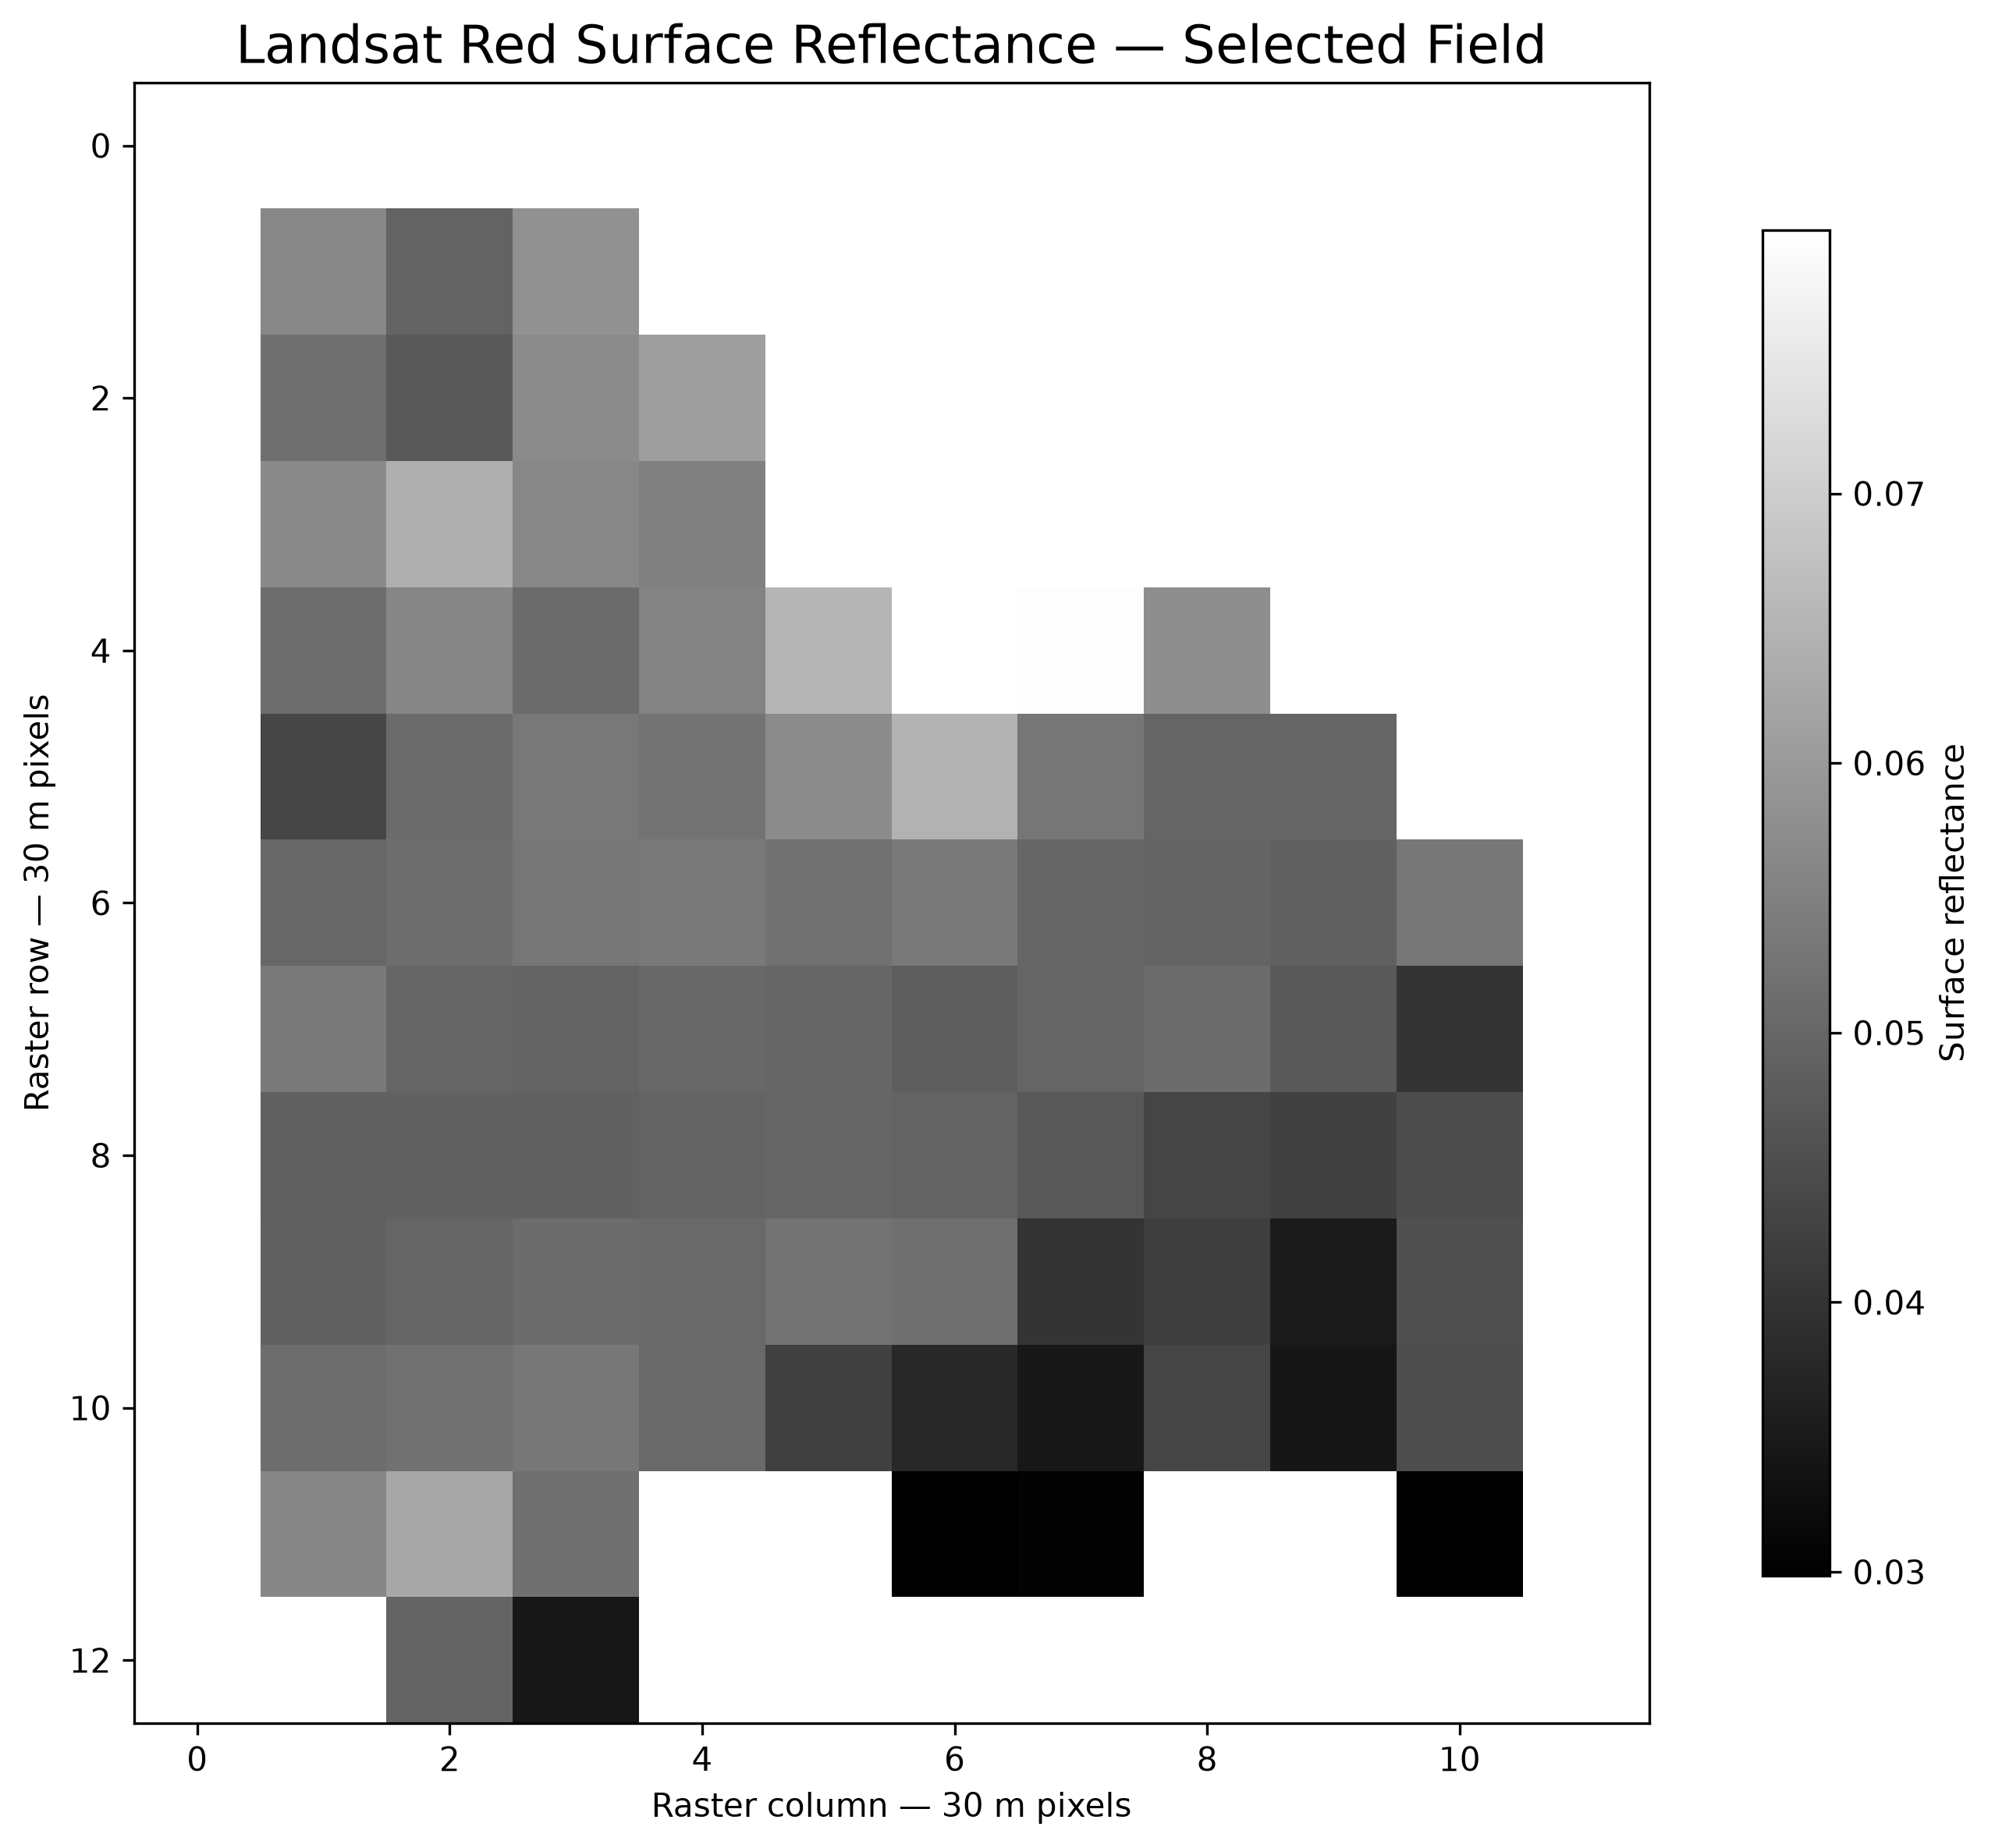

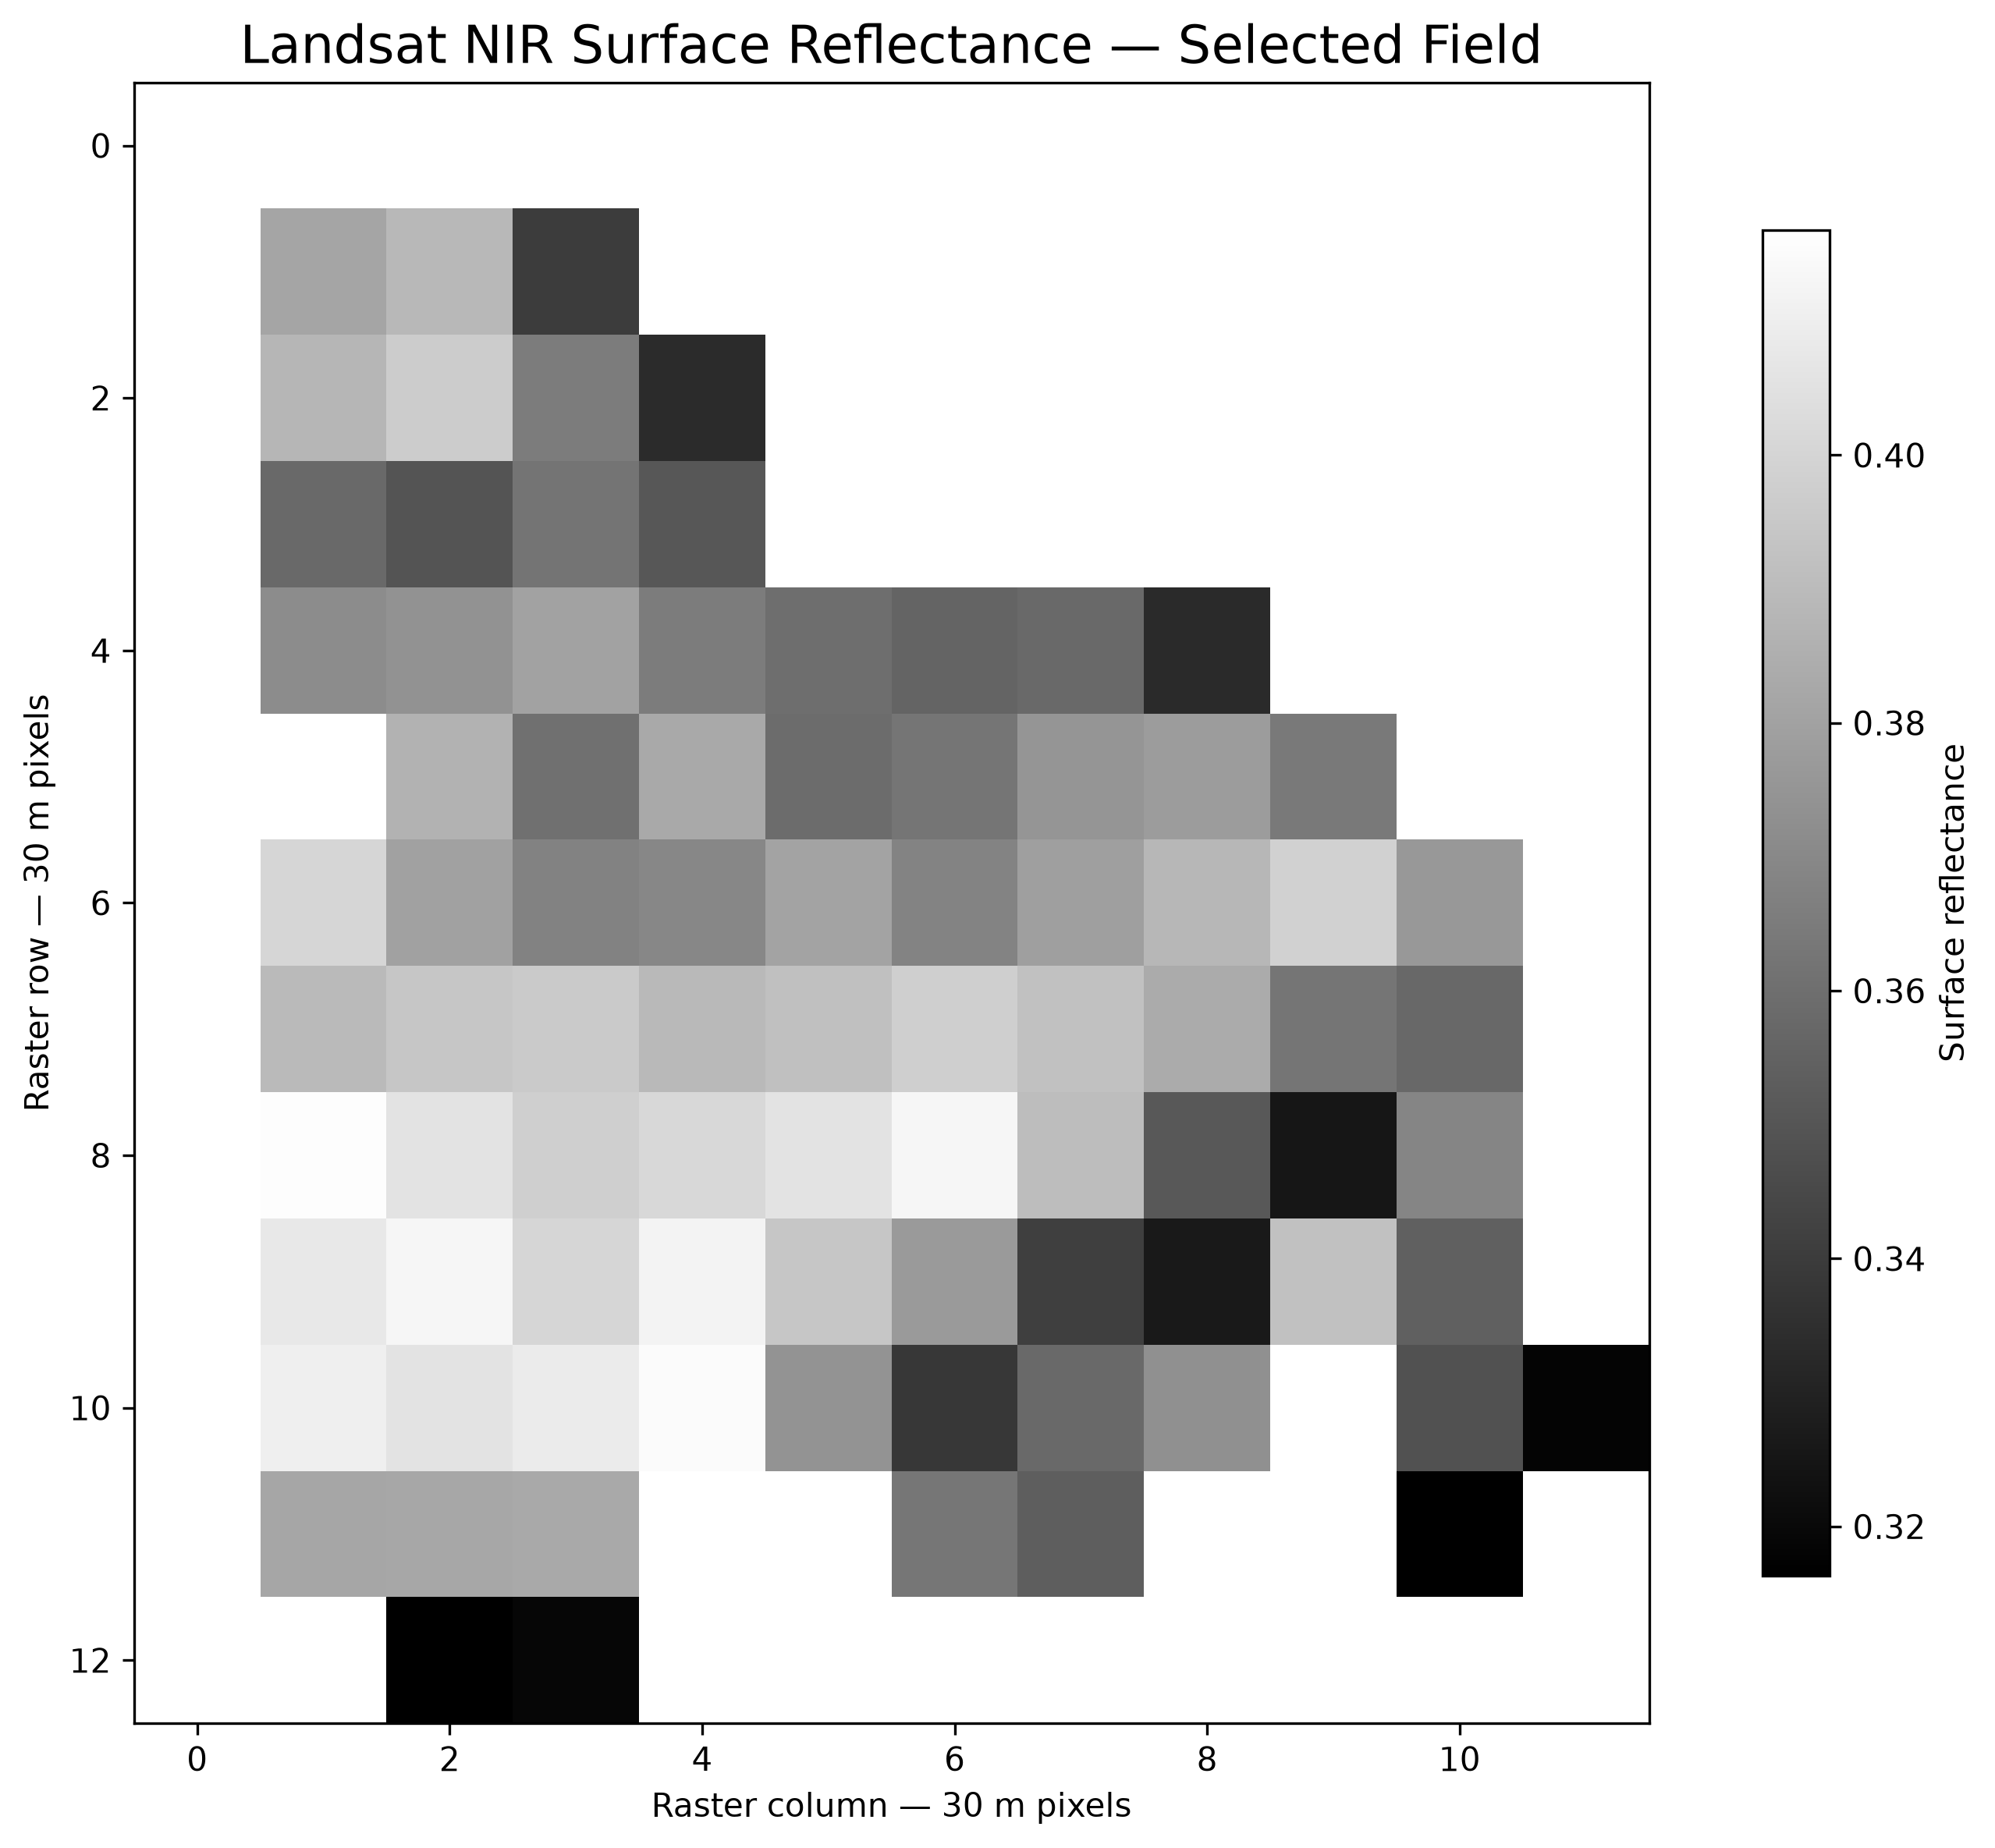

PASS: Single-band Red and NIR images displayed.


In [5]:
red_image = (
    A5
    / "output/visualizations/"
    / "01_selected_field_red_reflectance.png"
)

nir_image = (
    A5
    / "output/visualizations/"
    / "02_selected_field_nir_reflectance.png"
)

assert red_image.is_file()
assert nir_image.is_file()

display(Image.open(red_image))
display(Image.open(nir_image))

print("PASS: Single-band Red and NIR images displayed.")

## NDVI image

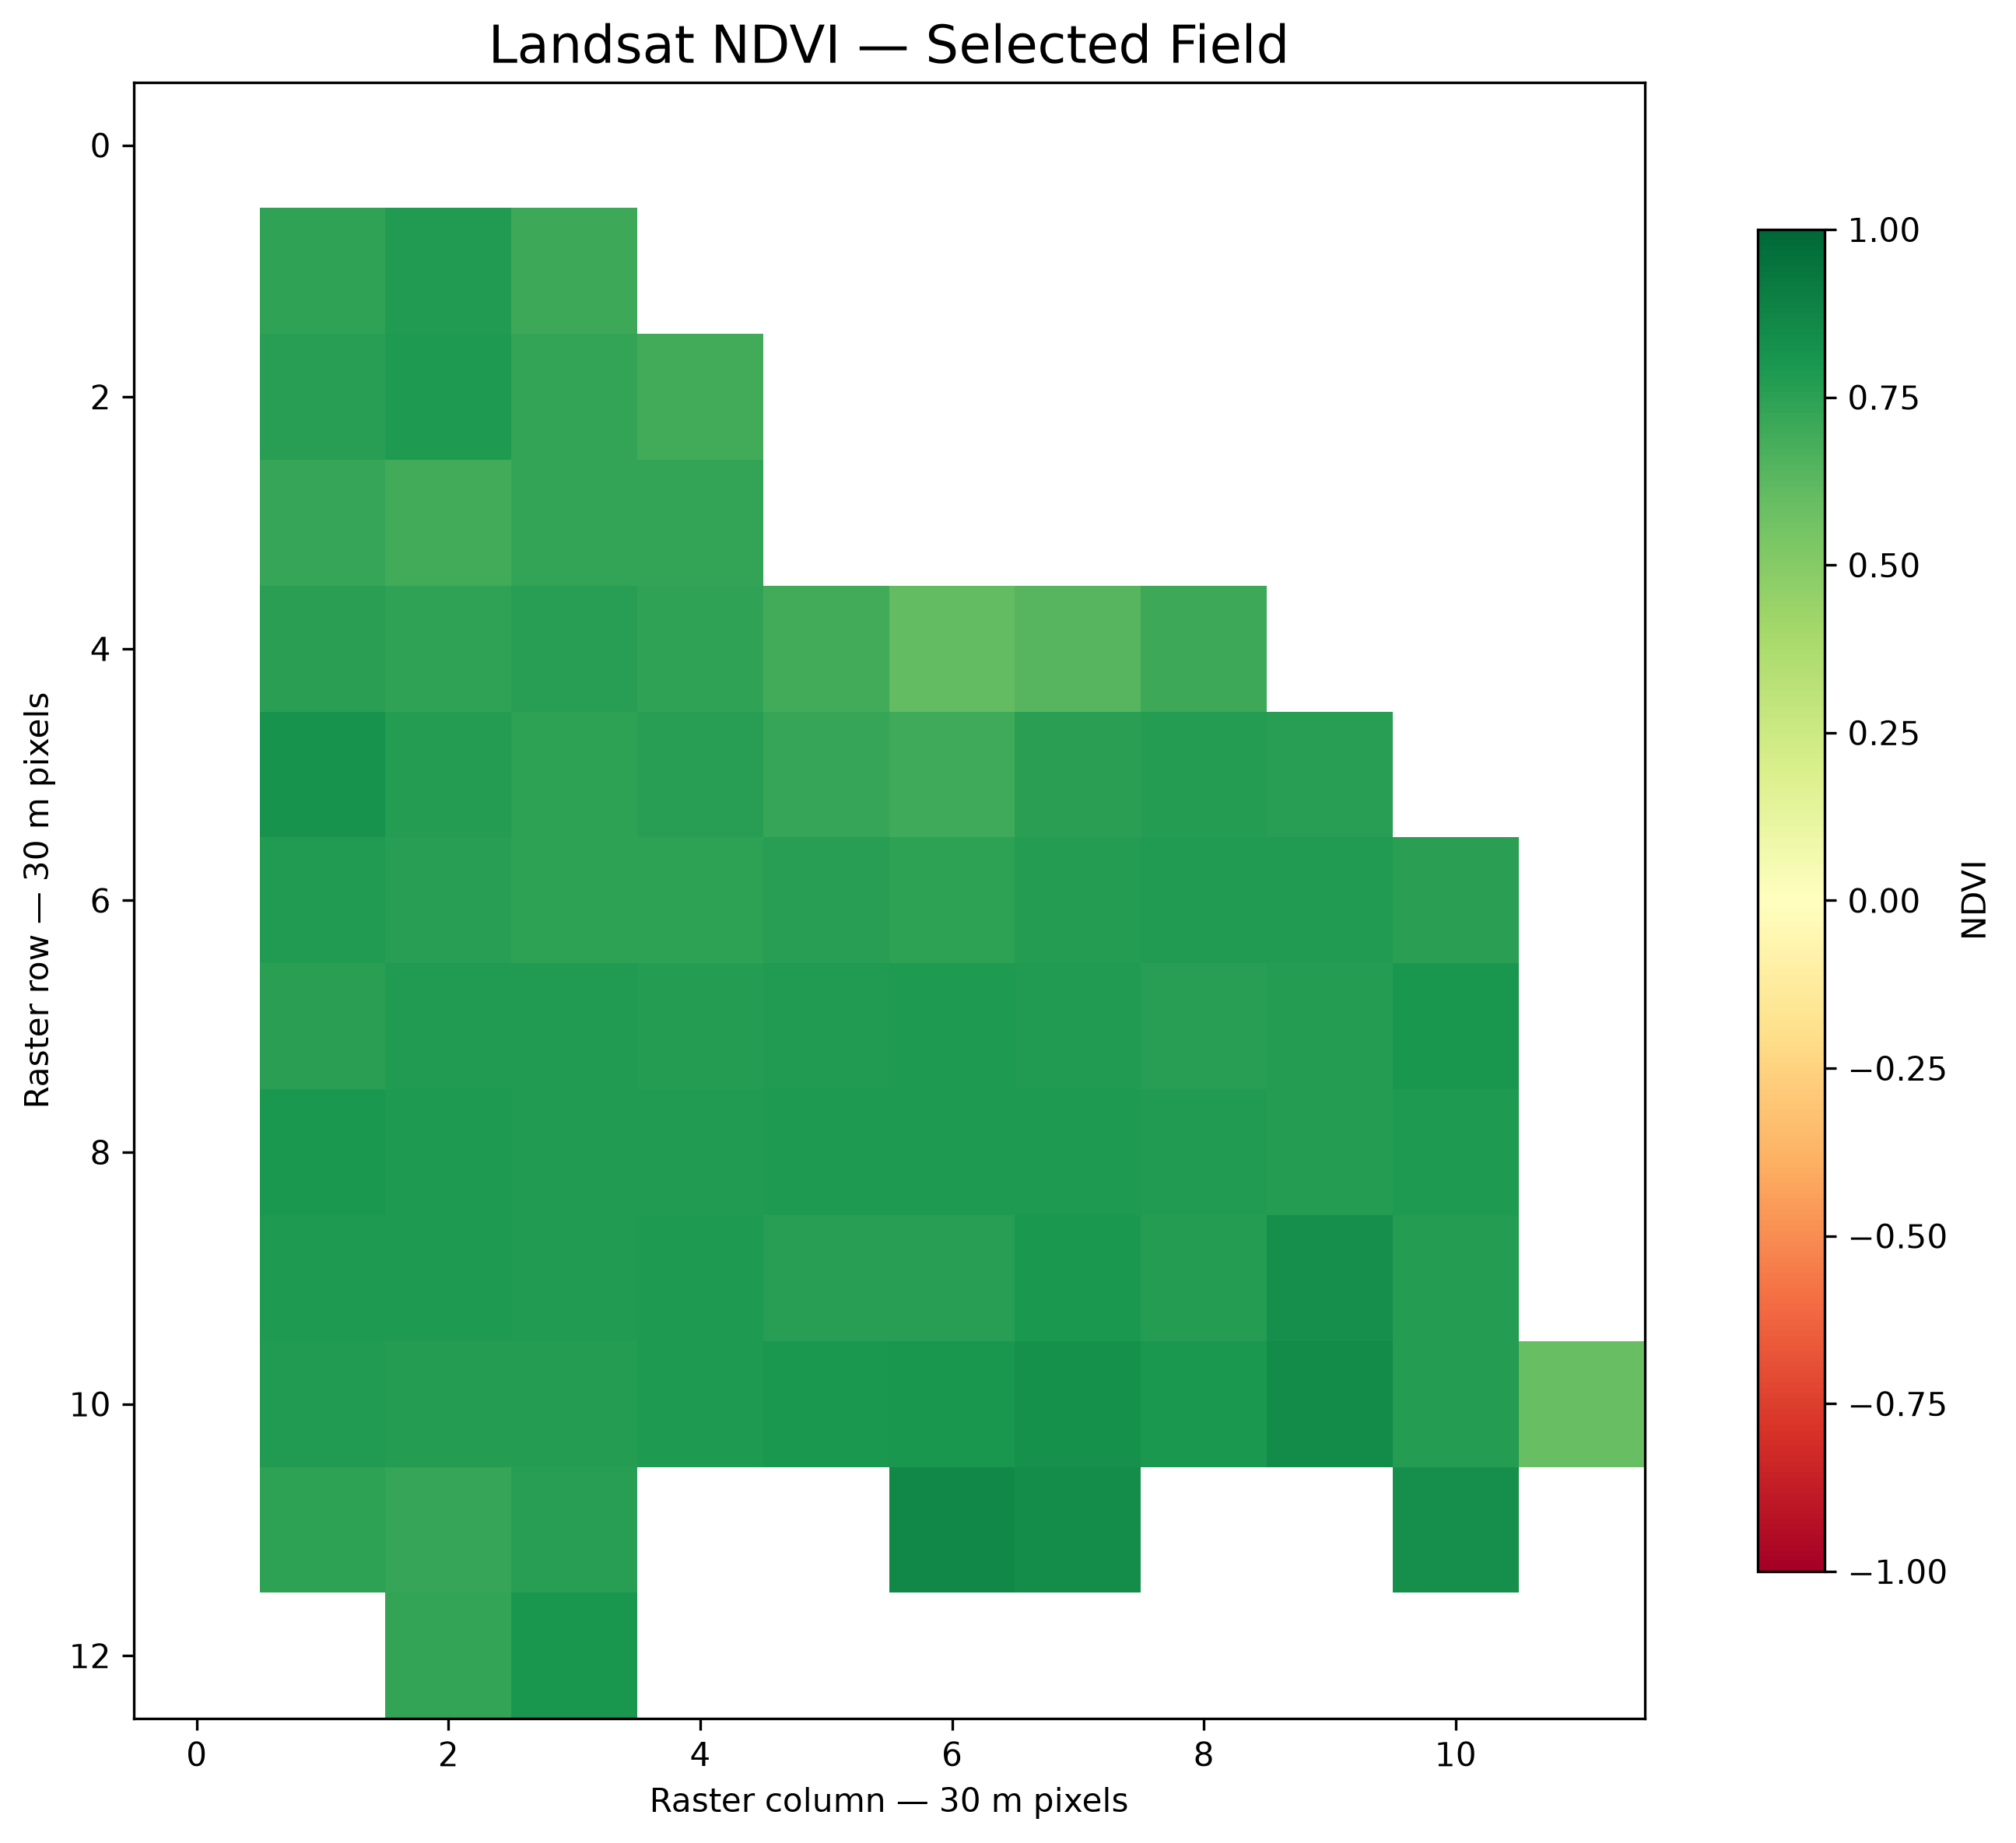

PASS: NDVI image displayed.


In [6]:
ndvi_image = (
    A5
    / "output/visualizations/"
    / "03_selected_field_ndvi.png"
)

assert ndvi_image.is_file()

display(Image.open(ndvi_image))

print("PASS: NDVI image displayed.")

## Field-level NDVI statistics

In [7]:
stats = summary["ndvi_statistics"]

statistics_table = pd.DataFrame(
    {
        "statistic": [
            "minimum",
            "median",
            "mean",
            "maximum",
            "standard deviation",
        ],
        "NDVI": [
            stats["minimum"],
            stats["median"],
            stats["mean"],
            stats["maximum"],
            stats["standard_deviation"],
        ],
    }
)

display(statistics_table)

print(
    "Field pixels:",
    summary["field_pixel_count"],
)
print(
    "Valid NDVI pixels:",
    summary["valid_pixel_count"],
)
print(
    "Valid NDVI percentage:",
    f"{summary['valid_pixel_percent']:.2f}%",
)
print(
    "Descriptive greenness:",
    summary["descriptive_greenness"],
)

assert stats["minimum"] >= -1.0
assert stats["maximum"] <= 1.0
assert stats["minimum"] <= stats["median"] <= stats["maximum"]
assert stats["minimum"] <= stats["mean"] <= stats["maximum"]

print("PASS: Field-level NDVI statistics validated.")

,statistic,NDVI
0,minimum,0.593474
1,median,0.769985
2,mean,0.762219
3,maximum,0.861223
4,standard deviation,0.043181


Field pixels: 87
Valid NDVI pixels: 87
Valid NDVI percentage: 100.00%
Descriptive greenness: high greenness
PASS: Field-level NDVI statistics validated.


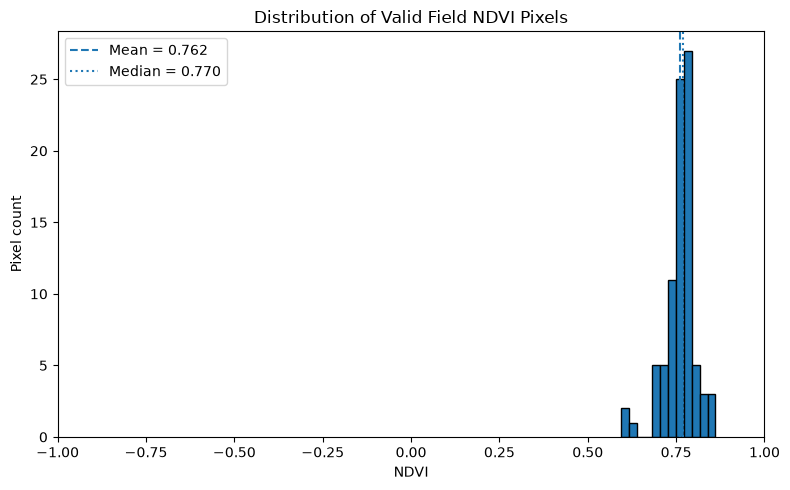

PASS: NDVI distribution plotted.


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    ndvi_valid,
    bins=12,
    edgecolor="black",
)

ax.axvline(
    stats["mean"],
    linestyle="--",
    label=f"Mean = {stats['mean']:.3f}",
)

ax.axvline(
    stats["median"],
    linestyle=":",
    label=f"Median = {stats['median']:.3f}",
)

ax.set_title("Distribution of Valid Field NDVI Pixels")
ax.set_xlabel("NDVI")
ax.set_ylabel("Pixel count")
ax.set_xlim(-1, 1)
ax.legend()

plt.tight_layout()
plt.show()

print("PASS: NDVI distribution plotted.")

## Interpretation

The selected field had **87 valid NDVI pixels**
from **87 field-intersecting Landsat pixels**.

The observed NDVI range was
**0.593 to
0.861**, with a median of
**0.770** and a mean of
**0.762**.

This represents **high greenness** for the acquisition
date. However, this is a descriptive single-date result at 30 m resolution.
It cannot independently diagnose crop health, crop stress, yield, management
quality, or the cause of spatial variation.

## Reproducibility and limitations

- Imagery source: authentic USGS Landsat Collection 2 Level-2 data
- Access route: Microsoft Planetary Computer
- Spatial resolution: 30 m
- Field boundary: authoritative Assignment 2 geometry
- Processing mode: offline after authenticated source-manifest validation
- Synthetic fallback: none
- Limitation: a small agricultural field contains relatively few Landsat
  pixels, and edge pixels may mix field and surrounding land cover.

In [9]:
def sha256(path):
    digest = hashlib.sha256()

    with path.open("rb") as file_obj:
        for block in iter(
            lambda: file_obj.read(1 << 20),
            b"",
        ):
            digest.update(block)

    return digest.hexdigest()


for relative_path, expected in summary["output_sha256"].items():
    path = ROOT / relative_path
    actual = sha256(path)

    assert actual == expected, relative_path

print("PASS: Analytical raster checksums match the NDVI summary.")
print("PASS: Assignment 5 notebook completed without errors.")

PASS: Analytical raster checksums match the NDVI summary.
PASS: Assignment 5 notebook completed without errors.
